# Домашнє завдання до модуля «Алгоритми навчання з вчителем Ч.3»
## Викачуємо дані

In [2]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/goitacademy/MACHINE-LEARNING-NEO/refs/heads/main/datasets/mod_04_hw_train_data.csv")

df.head()

,Name,Phone_Number,Experience,Qualification,University,Role,Cert,Date_Of_Birth,Salary
0,Jennifer Hernandez,120-602-1220,3.0,Msc,Tier2,Mid,Yes,25/08/1972,98000
1,Timothy Walker,840-675-8650,5.0,PhD,Tier2,Senior,Yes,03/12/2013,135500
2,David Duran,556-293-8643,5.0,Msc,Tier2,Senior,Yes,19/07/2002,123500
3,Gloria Ortega,463-559-7474,3.0,Bsc,Tier3,Mid,No,19/02/1970,85000
4,Matthew Steele,968-091-7683,5.0,Bsc,Tier2,Senior,Yes,20/02/1970,111500


## Переглядаємо та досліджуємо дані

In [3]:
df.dtypes

Name              object
Phone_Number      object
Experience       float64
Qualification     object
University        object
Role              object
Cert              object
Date_Of_Birth     object
Salary             int64
dtype: object

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Name           249 non-null    object 
 1   Phone_Number   249 non-null    object 
 2   Experience     247 non-null    float64
 3   Qualification  248 non-null    object 
 4   University     249 non-null    object 
 5   Role           246 non-null    object 
 6   Cert           247 non-null    object 
 7   Date_Of_Birth  249 non-null    object 
 8   Salary         249 non-null    int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 17.6+ KB


In [5]:
df.isna().mean().sort_values(ascending=False)

Role             0.012048
Experience       0.008032
Cert             0.008032
Qualification    0.004016
Name             0.000000
Phone_Number     0.000000
University       0.000000
Date_Of_Birth    0.000000
Salary           0.000000
dtype: float64

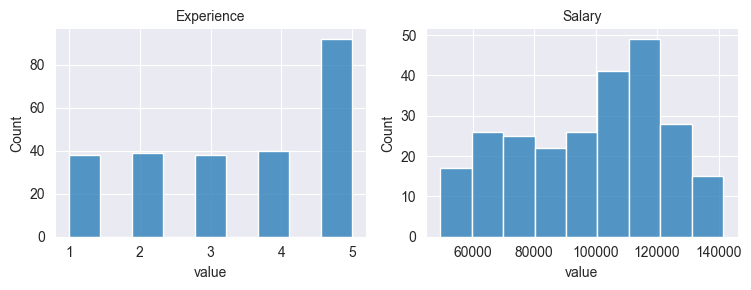

In [6]:
import numpy as np
from home_works.machine_learning.util import show_num_features_dist

data_num = df.select_dtypes(include=np.number)

show_num_features_dist(data_num)

## Видаляємо некорисні колонки
Зі спостережень бачимо, що колонки **Name** i **Phone_Nuber**, оскільки не несуть корисної інформації для моделі.

In [7]:
df.drop("Name", axis=1, inplace=True)
df.head()

,Phone_Number,Experience,Qualification,University,Role,Cert,Date_Of_Birth,Salary
0,120-602-1220,3.0,Msc,Tier2,Mid,Yes,25/08/1972,98000
1,840-675-8650,5.0,PhD,Tier2,Senior,Yes,03/12/2013,135500
2,556-293-8643,5.0,Msc,Tier2,Senior,Yes,19/07/2002,123500
3,463-559-7474,3.0,Bsc,Tier3,Mid,No,19/02/1970,85000
4,968-091-7683,5.0,Bsc,Tier2,Senior,Yes,20/02/1970,111500


In [8]:
df.drop("Phone_Number", axis=1, inplace=True)
df.head()

,Experience,Qualification,University,Role,Cert,Date_Of_Birth,Salary
0,3.0,Msc,Tier2,Mid,Yes,25/08/1972,98000
1,5.0,PhD,Tier2,Senior,Yes,03/12/2013,135500
2,5.0,Msc,Tier2,Senior,Yes,19/07/2002,123500
3,3.0,Bsc,Tier3,Mid,No,19/02/1970,85000
4,5.0,Bsc,Tier2,Senior,Yes,20/02/1970,111500


## Перетворюємо поле дати народження в числове поле
Саме дата народження **Date_Of_Birth** не несе жодного корисного навантаження. Натомість колонка віку кандидата може допомогти моделі краще прогнозувати заробітну плату.

In [9]:
df["Date_Of_Birth"] = pd.to_datetime(df["Date_Of_Birth"], format="%d/%m/%Y", errors="coerce")
df.head()

,Experience,Qualification,University,Role,Cert,Date_Of_Birth,Salary
0,3.0,Msc,Tier2,Mid,Yes,1972-08-25,98000
1,5.0,PhD,Tier2,Senior,Yes,2013-12-03,135500
2,5.0,Msc,Tier2,Senior,Yes,2002-07-19,123500
3,3.0,Bsc,Tier3,Mid,No,1970-02-19,85000
4,5.0,Bsc,Tier2,Senior,Yes,1970-02-20,111500


In [10]:
import datetime

df["Age"] = df.apply(lambda d: (pd.Timestamp.today().normalize() - d["Date_Of_Birth"]).days // 365, axis=1)
df.drop("Date_Of_Birth", axis=1, inplace=True)

df.head()

,Experience,Qualification,University,Role,Cert,Salary,Age
0,3.0,Msc,Tier2,Mid,Yes,98000,53
1,5.0,PhD,Tier2,Senior,Yes,135500,11
2,5.0,Msc,Tier2,Senior,Yes,123500,23
3,3.0,Bsc,Tier3,Mid,No,85000,55
4,5.0,Bsc,Tier2,Senior,Yes,111500,55


## Перетворення категоріального поля сертифікації у числовий формат

Оскільки поле **Cert** має лише 2 значення: *Yes* i *No*, нам зручно буде закодувати **Yes** => *1*, **No** => *0*.

In [11]:
df["Cert"] = df["Cert"].map({"Yes": 1, "No": 0})

df.head()

,Experience,Qualification,University,Role,Cert,Salary,Age
0,3.0,Msc,Tier2,Mid,1.0,98000,53
1,5.0,PhD,Tier2,Senior,1.0,135500,11
2,5.0,Msc,Tier2,Senior,1.0,123500,23
3,3.0,Bsc,Tier3,Mid,0.0,85000,55
4,5.0,Bsc,Tier2,Senior,1.0,111500,55


## А тепер проведемо кодування, відновлення пропущених значень та стандартизацію даних

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, TargetEncoder, KBinsDiscretizer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

X = df.drop("Salary", axis=1)
y = df["Salary"]

numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
from sklearn.preprocessing import OneHotEncoder

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    # Якщо наполягаєте на таргет-енкодингу, замініть на ваш TargetEncoder()
    ("target_encoder", OneHotEncoder()),
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

prep = ColumnTransformer(transformers=[
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
], remainder="drop", verbose_feature_names_out=False)

# Створюємо повний пайплайн (за потреби)
full_pipe = Pipeline(steps=[
    ("prep", prep)
])

X_trans = full_pipe.fit_transform(X, y)

ohe = full_pipe.named_steps["prep"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(categorical_cols))
feature_names = numeric_cols + cat_feature_names

X_trans = pd.DataFrame(X_trans, columns=feature_names, index=getattr(X, "index", None))

X_trans.head()

,Experience,Cert,Age,Qualification_Bsc,Qualification_Msc,Qualification_PhD,Qualification_nan,University_Tier1,University_Tier2,University_Tier3,Role_Junior,Role_Mid,Role_Senior,Role_nan
0,-0.299532,0.949086,1.357034,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,1.044315,0.949086,-2.144535,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.044315,0.949086,-1.144087,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-0.299532,-1.053646,1.523775,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,1.044315,0.949086,1.523775,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## Розділяємо дані на тренувальні та тестові

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_trans, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

## Будуємо модель, навчаємо, проводимо прогноз та оцінюємо якість моделі

In [14]:
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.neighbors import KNeighborsRegressor

k_neighbors_regression = KNeighborsRegressor()

k_neighbors_regression.fit(X_train, y_train)

y_pred = k_neighbors_regression.predict(X_test)

mape = mean_absolute_percentage_error(y_test, y_pred)

print(f'Validation MAPE: {mape:.2%}')

Validation MAPE: 4.84%


## Висновки

Для досягнення поставленої задачі довелось певним чином модифікувати дані для верифікаційної вибірки:
- Видалити колонки, котрі не несуть корисного навантаження для моделі, натомість можуть спричинити помилки
- Створити колонку з віком на основі дати народження, вважаючи, що вік впливає на заробітну плату
- Провести заповнення відсутніх даних значеннями найближчих сусідів
- Провести кодифікацію категоріальних даних через **OneHotEncoder**

Як бачимо, правильна обробка даних дає хороший результат по прогнозуванню.